### Project Overview
This notebook explores the California Housing dataset using various machine learning models to predict housing prices. We’ll perform data preprocessing, feature engineering, and model evaluation using ElasticNet, Decision Tree, Random Forest, and XGBoost.

In [4]:
! uv pip install pandas
! uv pip install scikit-learn
! uv pip install matplotlib
! uv pip install seaborn
! uv pip install numpy
! uv pip install xgboost

Audited 1 package in 17ms
Audited 1 package in 6ms
Audited 1 package in 6ms
Audited 1 package in 5ms
Audited 1 package in 1ms
Resolved 3 packages in 166ms                                         
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/2.22 MiB            
⠙ Preparing packages... (0/1)------------------- 16.00 KiB/2.22 MiB          
⠙ Preparing packages... (0/1)------------------- 32.00 KiB/2.22 MiB          
⠙ Preparing packages... (0/1)------------------- 48.00 KiB/2.22 MiB          
⠙ Preparing packages... (0/1)------------------- 63.03 KiB/2.22 MiB          
⠙ Preparing packages... (0/1)------------------- 79.03 KiB/2.22 MiB          
⠙ Preparing packages... (0/1)------------------- 95.03 KiB/2.22 MiB          
⠙ Preparing packages... (0/1)------------------- 111.03 KiB/2.22 MiB         
⠙ Preparing packages... (0/1)------------------- 127.03 KiB/2.22 MiB         
⠙ Preparing packages.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

In [8]:
# Load the California housing dataset, which contains features like median income, house age, etc., to predict median house values.
california = fetch_california_housing(as_frame=True)
df = california.frame

### Dataset Description
The California Housing dataset contains 20,640 samples with 8 features (e.g., median income, house age) and a target variable, `MedHouseVal` (median house value in $100,000s).

In [9]:
df.shape

(20640, 9)

In [10]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

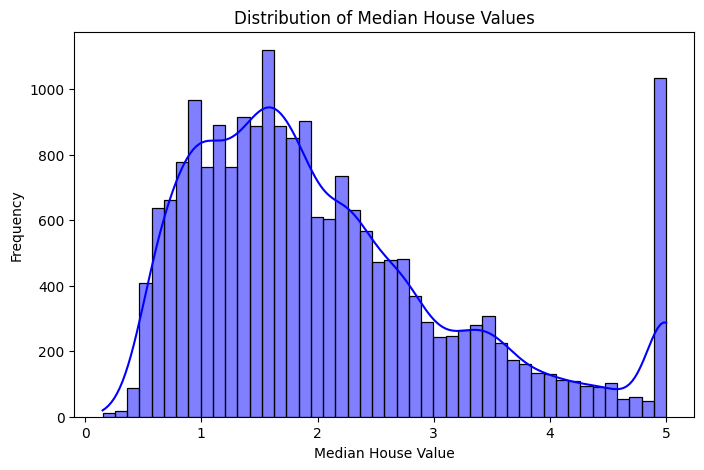

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], kde=True, color='blue')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

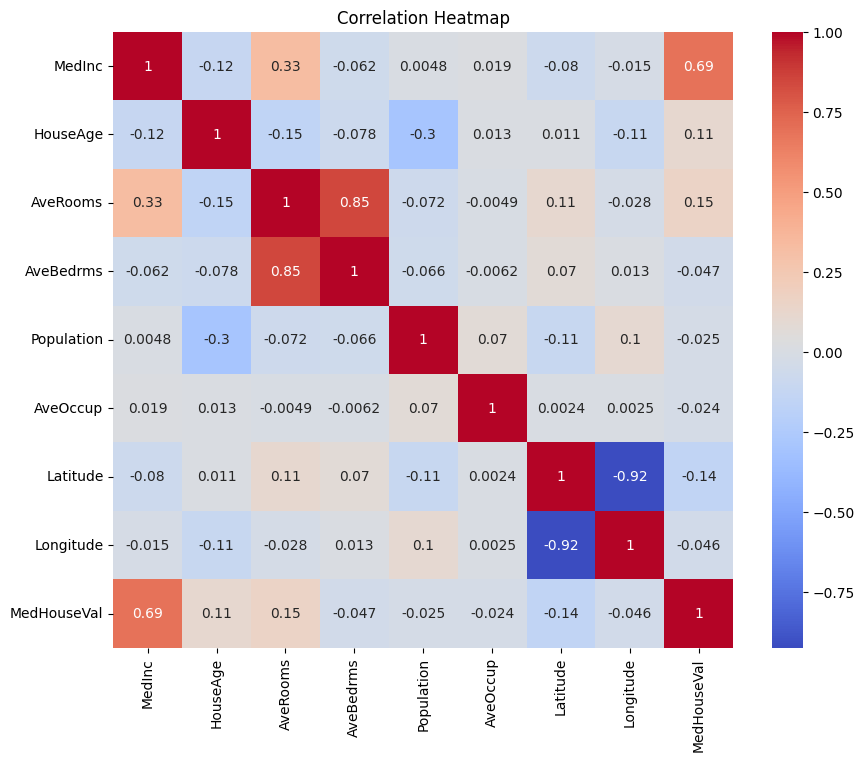

In [15]:
# Check correlations to understand which features might be most influential in predicting median house values.
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlations)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


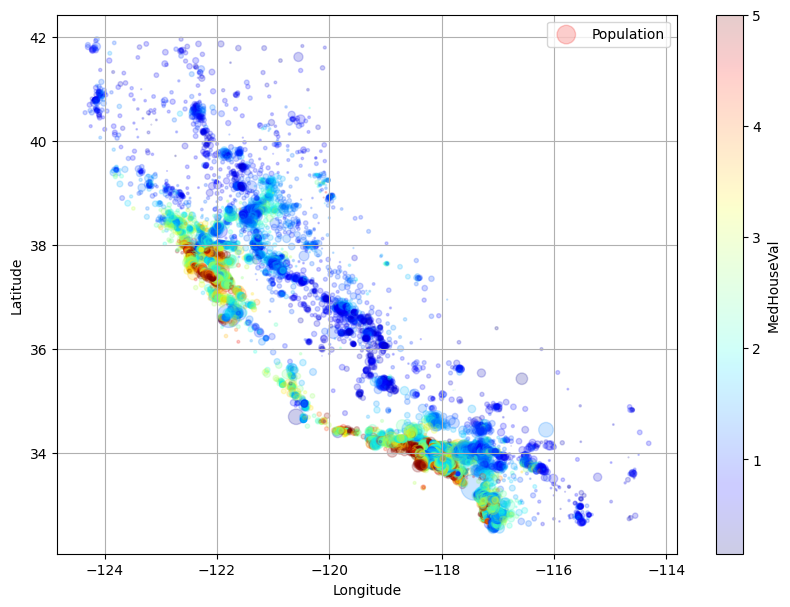

California Housing:
Circle Size : Large (Dense Population) <-> Small (Thin Population)
Color : Red(Expensive) <-> Blue(Cheap)


In [17]:
df.plot(kind='scatter', x='Longitude', y='Latitude', grid=True, alpha=0.2,
             s=df["Population"]/100, label="Population",
             c="MedHouseVal", cmap='jet',colorbar=True,
             legend=True, sharex=False, figsize=(10,7))
plt.show()
print(f"""California Housing:
Circle Size : Large (Dense Population) <-> Small (Thin Population)
Color : Red(Expensive) <-> Blue(Cheap)""")

### Feature Engineering
We’ll create additional features to capture more nuanced relationships in the data, such as the number of households and room distributions, which may improve model performance.

In [19]:
# Calculate the number of households based on population and average occupancy
df['Households'] = df['Population'] / df['AveOccup']

# Average rooms per household to understand housing density
df['RoomsPerHousehold'] = df['AveRooms'] / df['Households']

# Ratio of bedrooms to total rooms, which might indicate housing type or affordability
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']

### Outlier Removal
Outliers can skew model performance, so we’ll use the Interquartile Range (IQR) method to remove extreme values. This step reduces noise in the dataset.

In [20]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

In [21]:
lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

In [22]:
df_clean = df[~((df < lb) | (df > ub)).any(axis=1)]

In [23]:
print(f"{df.shape[0] - df_clean.shape[0]} rows removed due to outliers.")

5679 rows removed due to outliers.


In [24]:
# Split the data into features (X) and target (y, i.e., median house value)
X = df_clean.drop('MedHouseVal', axis=1)
y = df_clean['MedHouseVal']

In [25]:
# Split the data into 80% training and 20% test sets for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (11968, 11)
Test set shape: (2993, 11)


### Model Evaluation Function
This function calculates and prints key metrics (MAE, MSE, RMSE, R²) to assess model performance on the test set.

In [26]:
def evaluate_model(model, X_test, y_test, name="Model"):

  # Predict on the test set and compute evaluation metrics
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)
  print(f"--- {name} Evaluation on Test Set ---")
  print(f"MAE: {mae:.4f}")
  print(f"MSE: {mse:.4f}")
  print(f"RMSE: {rmse:.4f}")
  print(f"R² Score: {r2:.4f}")

### Hyperparameter Tuning Function
This function uses RandomizedSearchCV to find the best hyperparameters for a given model and then evaluates the best model on the test set.

In [27]:
def tune_and_evaluate_model(model, param_grid, X_train, y_train, X_test, y_test, name, n_iter=10, cv=5):

  # Perform hyperparameter tuning using RandomizedSearchCV
  random_search = RandomizedSearchCV(
      model, param_grid, n_iter=n_iter, cv=cv, scoring='r2', n_jobs=-1, random_state=42
  )
  random_search.fit(X_train, y_train)
  print(f"Best Parameters (RandomizedSearchCV) for {name}: {random_search.best_params_}")
  print(f"Best R² Score (RandomizedSearchCV) for {name}: {random_search.best_score_}")

  best_model = random_search.best_estimator_
  # Evaluate the best model on the test set
  evaluate_model(best_model, X_test, y_test, name=f"{name} RandomizedSearchCV")
  return best_model

### Linear Regression (Baseline)
Linear Regression is a simple, foundational model that assumes a linear relationship between features and the target variable. We’ll use it as a baseline to compare against more complex models, without any hyperparameter tuning or additional preprocessing, to establish a performance reference point.

In [28]:
# Baseline Model: Simple Linear Regression
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
evaluate_model(baseline_model, X_test, y_test, name="Baseline Linear Regression")

--- Baseline Linear Regression Evaluation on Test Set ---
MAE: 0.4177
MSE: 0.3009
RMSE: 0.5486
R² Score: 0.6576


### ElasticNet with Polynomial Features
We’ll use a pipeline that scales the data, generates polynomial features, and applies ElasticNet regression. This model combines L1 and L2 regularization, which can handle multicollinearity and feature selection.

In [29]:
# ElasticNet with Polynomial Features
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('elastic', ElasticNet(max_iter=10000, random_state=42))
])

# Parameter grid for ElasticNet
# - 'poly__degree': Testing degrees 1 to 3 to capture linear and non-linear relationships.
# - 'elastic__alpha': Testing a range from 0.01 to 10 to explore different regularization strengths.
# - 'elastic__l1_ratio': Testing 0.1, 0.5, 0.9 to balance between L1 (lasso) and L2 (ridge) regularization.
param_grid_elastic = {
    'poly__degree': [1, 2, 3],
    'elastic__alpha': [0.01, 0.1, 1, 10],
    'elastic__l1_ratio': [0.1, 0.5, 0.9]
}

best_elastic = tune_and_evaluate_model(
    pipeline, param_grid_elastic, X_train, y_train, X_test, y_test, name="ElasticNet", n_iter=20, cv=5
)

Best Parameters (RandomizedSearchCV) for ElasticNet: {'poly__degree': 3, 'elastic__l1_ratio': 0.5, 'elastic__alpha': 0.01}
Best R² Score (RandomizedSearchCV) for ElasticNet: 0.7121523737128997
--- ElasticNet RandomizedSearchCV Evaluation on Test Set ---
MAE: 0.3822
MSE: 0.2659
RMSE: 0.5156
R² Score: 0.6975


### Decision Tree Regressor
A Decision Tree is a simple, interpretable model that can capture non-linear relationships. We’ll tune its depth and leaf parameters to prevent overfitting.

In [30]:
# Decision Tree
model_dt = DecisionTreeRegressor(random_state=42)

# Parameter grid for Decision Tree
# - 'max_depth': Testing depths 5, 10, 20 to balance model complexity and overfitting.
# - 'min_samples_split': Testing 2, 5, 10 to control when to stop splitting nodes.
# - 'min_samples_leaf': Testing 1, 2, 4 to ensure leaves have enough samples for generalization.
param_grid_dt = {
    'max_depth': [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5, 10]
}
best_dt = tune_and_evaluate_model(
    model_dt, param_grid_dt, X_train, y_train, X_test, y_test, name="Decision Tree", n_iter=20, cv=5
)

Best Parameters (RandomizedSearchCV) for Decision Tree: {'min_samples_split': 2, 'min_samples_leaf': 10, 'max_depth': 15}
Best R² Score (RandomizedSearchCV) for Decision Tree: 0.6634543470046567
--- Decision Tree RandomizedSearchCV Evaluation on Test Set ---
MAE: 0.3739
MSE: 0.2902
RMSE: 0.5387
R² Score: 0.6699


### Random Forest Regressor
Random Forest is an ensemble of Decision Trees that reduces overfitting and improves generalization. We’ll tune the number of trees and depth for optimal performance.

In [31]:
# Random Forest
model_rf = RandomForestRegressor(random_state=42)

# Parameter grid for Random Forest
# - 'n_estimators': Testing 100 and 150 trees to balance performance and computation time.
# - 'max_depth': Testing 10 and 20 to control tree depth and prevent overfitting.
# - 'min_samples_split': Testing 2 and 5 to manage when to stop splitting.
# - 'min_samples_leaf': Testing 1 and 2 to ensure leaf nodes have sufficient samples.
param_grid_rf = {
    'n_estimators': [80, 100],
    'max_depth': [8, 10],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}
best_rf = tune_and_evaluate_model(
    model_rf, param_grid_rf, X_train, y_train, X_test, y_test, name="Random Forest", n_iter=10, cv=3
)

Best Parameters (RandomizedSearchCV) for Random Forest: {'n_estimators': 80, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 10}
Best R² Score (RandomizedSearchCV) for Random Forest: 0.7618732776214738
--- Random Forest RandomizedSearchCV Evaluation on Test Set ---
MAE: 0.3251
MSE: 0.2127
RMSE: 0.4612
R² Score: 0.7580


### XGBoost Regressor
XGBoost is a powerful gradient boosting algorithm known for its speed and performance. It’s particularly effective for structured data like this housing dataset.

In [32]:
# XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Parameter grid for XGBoost
# - 'n_estimators': Testing 100, 200, 300 to find the optimal number of boosting rounds.
# - 'learning_rate': Testing 0.01, 0.05, 0.1 to balance convergence speed and stability.
# - 'max_depth': Testing 3, 5, 7 to control the complexity of individual trees.
# - 'min_child_weight': Testing 1, 3, 5 to prevent overfitting by requiring a minimum sum of instance weights in a child.
# - 'subsample': Testing 0.7, 0.8, 1.0 to control the fraction of samples used for training each tree.
# - 'colsample_bytree': Testing 0.7, 0.8, 1.0 to control the fraction of features used for each tree.
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
best_xgb = tune_and_evaluate_model(
    xgb_model, param_grid_xgb, X_train, y_train, X_test, y_test, name="XGBoost", n_iter=10, cv=5
)

Best Parameters (RandomizedSearchCV) for XGBoost: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best R² Score (RandomizedSearchCV) for XGBoost: 0.835337034342827
--- XGBoost RandomizedSearchCV Evaluation on Test Set ---
MAE: 0.2699
MSE: 0.1474
RMSE: 0.3840
R² Score: 0.8323


### Model Comparison
- **XGBoost**: Best performer with R² = 0.8338, RMSE = 0.3822, due to its gradient boosting strength.  
- **Random Forest**: R² = 0.7584, solid but less effective than XGBoost.  
- **ElasticNet** (R² = 0.6899) and **Decision Tree** (R² = 0.6438) lagged behind, likely due to simpler modeling approaches.

### Predicted vs. Actual Values
This plot compares the model’s predictions to actual values. Points near the red line show accurate predictions.

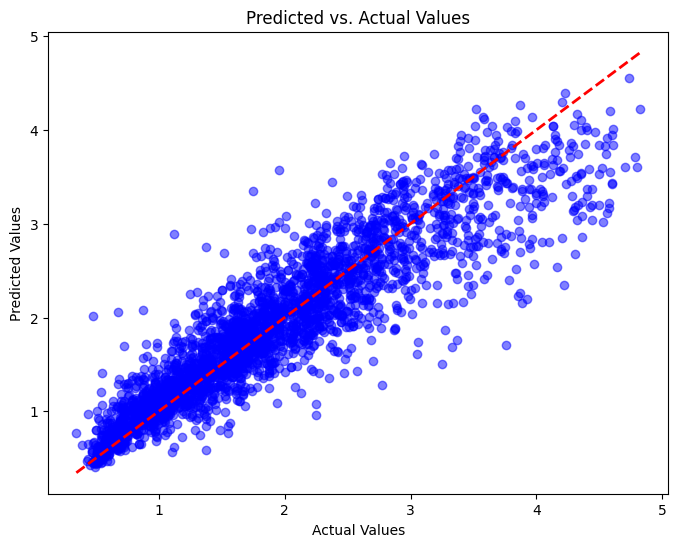

In [33]:
y_pred = best_xgb.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Values')
plt.show()

### Feature Importance
This plot shows the top features driving the model’s predictions, based on their contribution to accuracy.

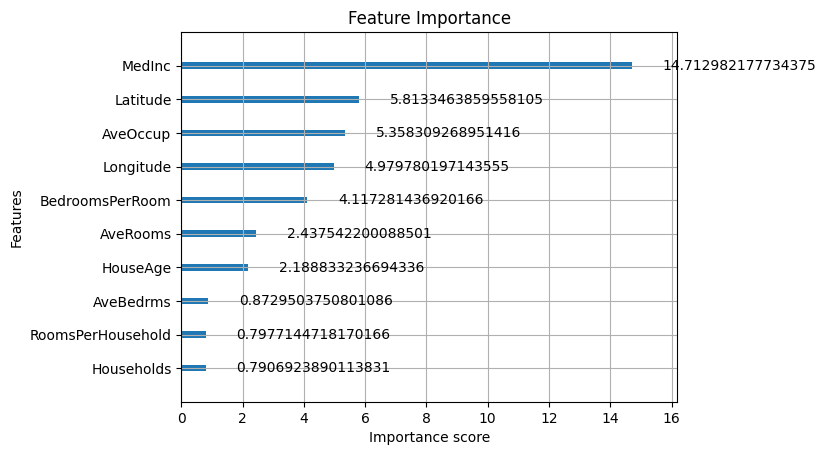

In [34]:
xgb.plot_importance(best_xgb, importance_type='gain', max_num_features=10, title='Feature Importance')
plt.show()